In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv('wine.csv')
df

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [3]:
df.shape

(178, 14)

In [4]:
df.size

2492

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [6]:
df.isnull().sum()

Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


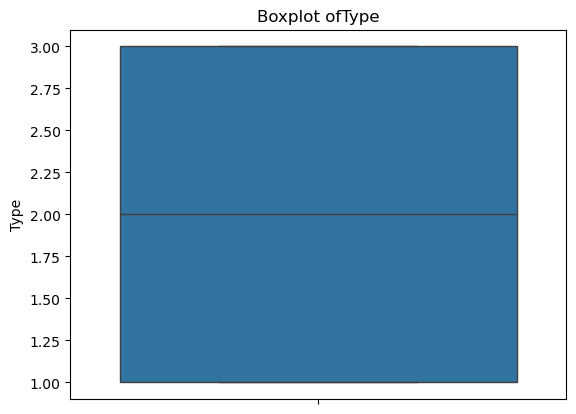

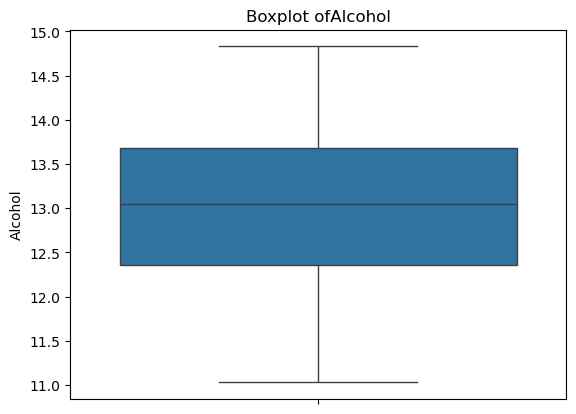

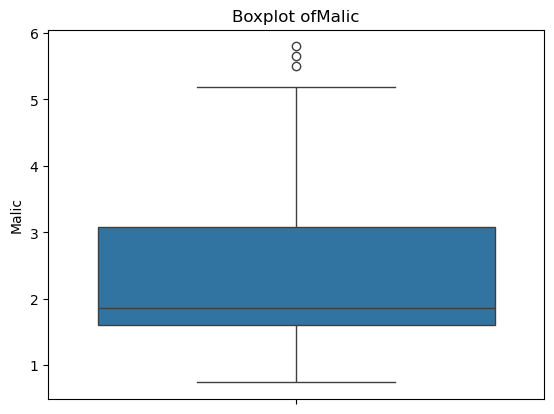

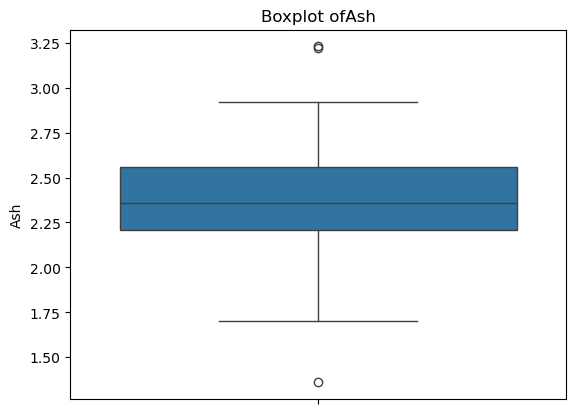

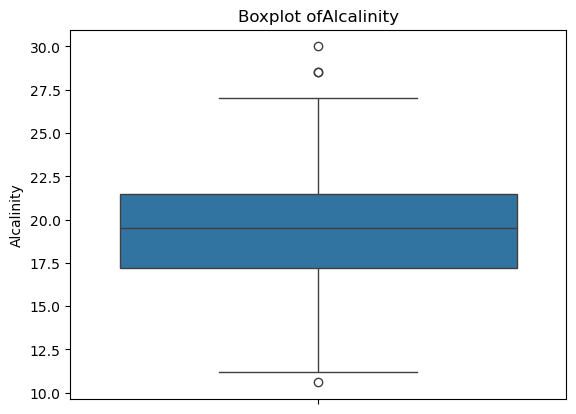

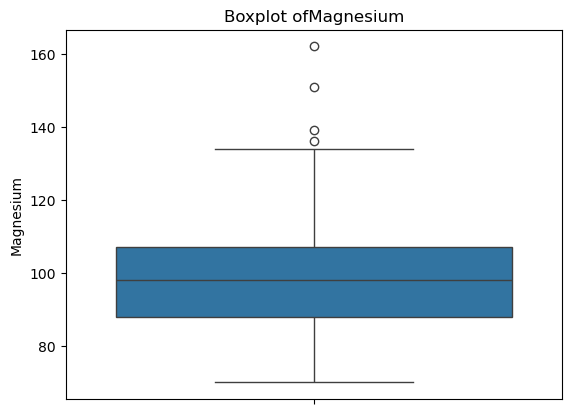

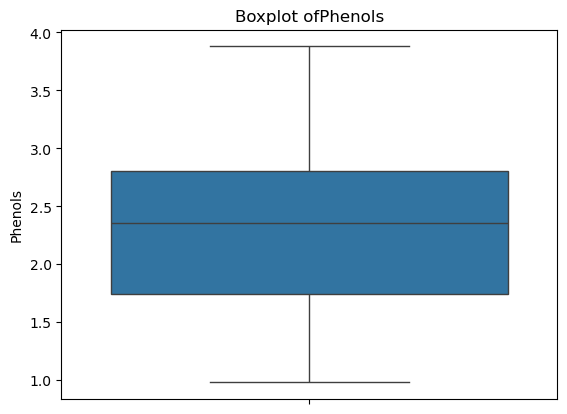

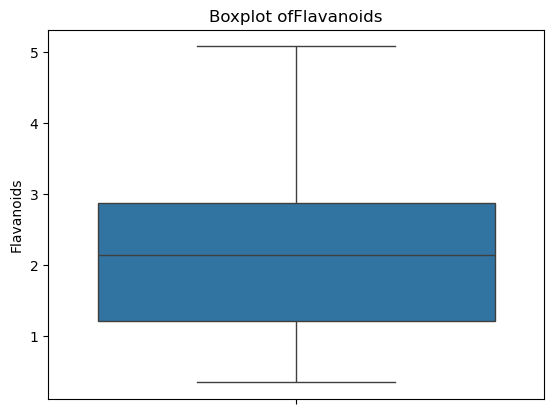

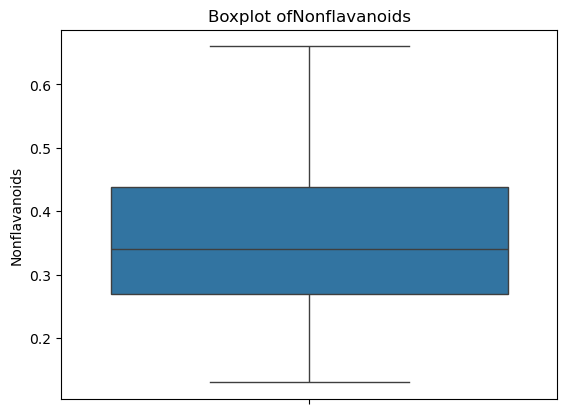

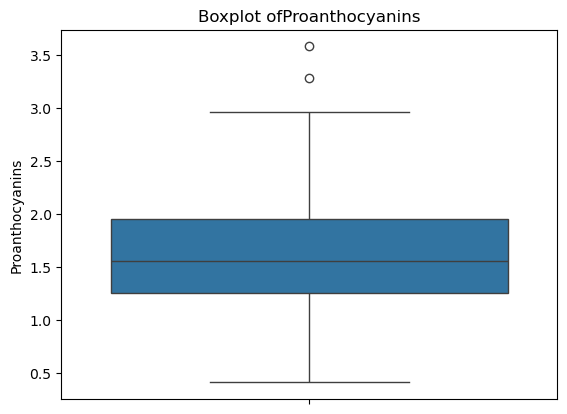

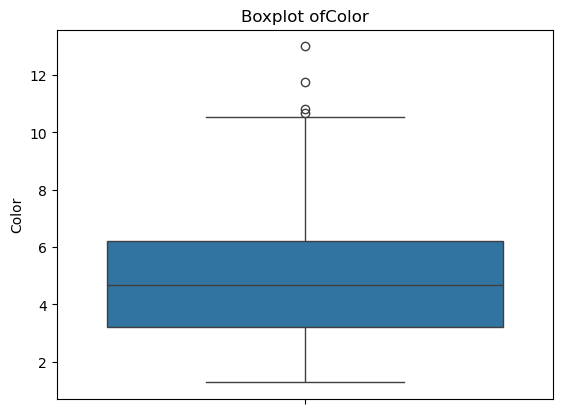

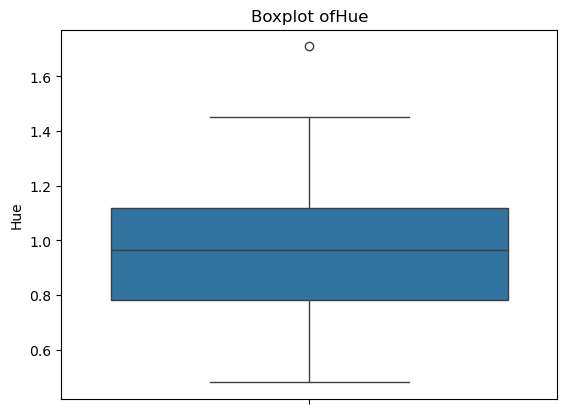

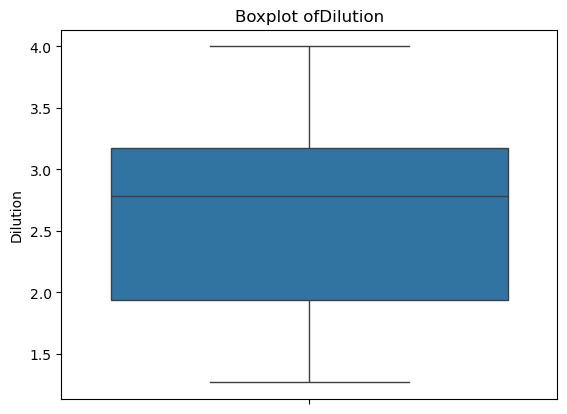

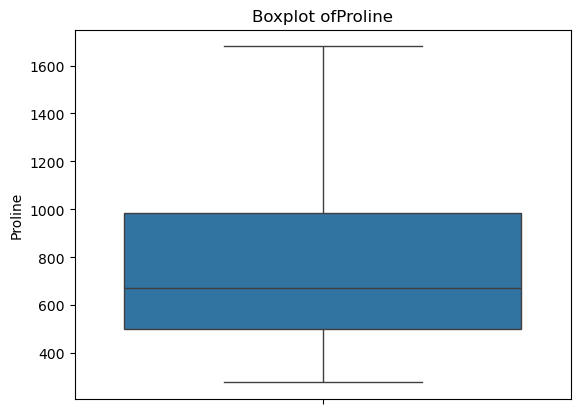

In [9]:
for col in df.select_dtypes(include=['int','float']).columns:
    sns.boxplot(df[col])
    plt.title(f"Boxplot of{col}")
    plt.show()

In [10]:
#Oiutlier capping
for i in df.select_dtypes(include=['int','float']).columns:
    q1=df[i].quantile(0.25)
    q3=df[i].quantile(0.75)
    IQR=q3-q1
    lower_bound=q1-1.5*IQR
    upper_bound=q3+1.5*IQR
    df[i]=df[i].clip(lower_bound,upper_bound)

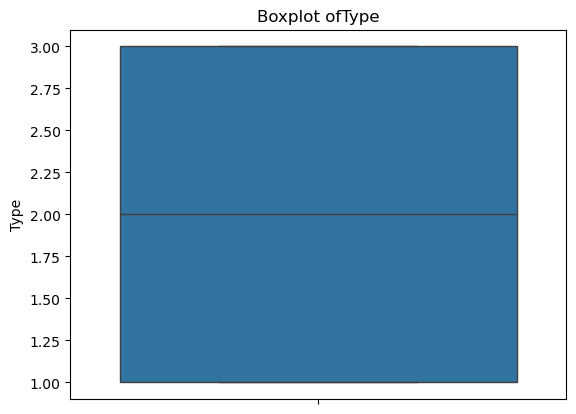

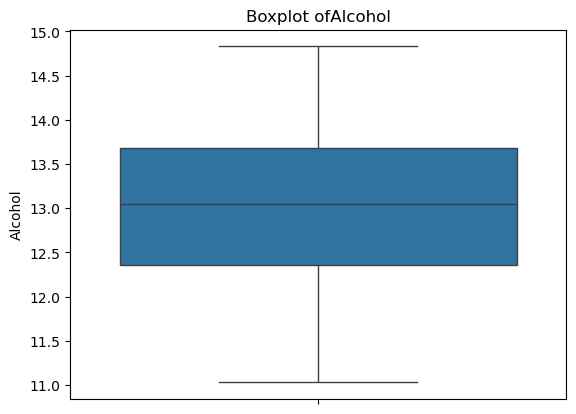

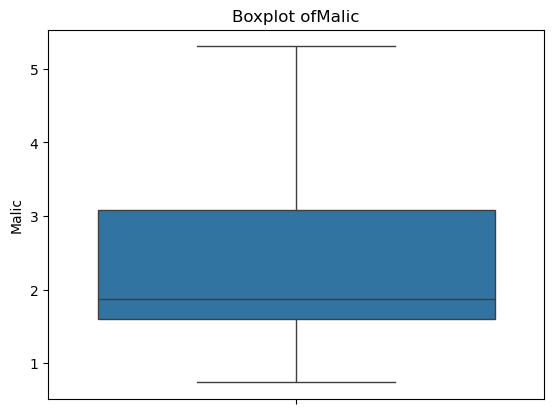

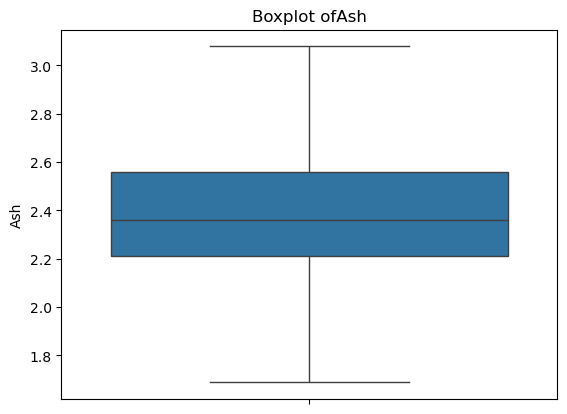

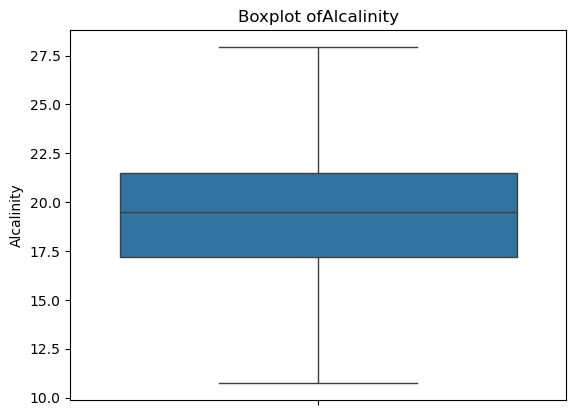

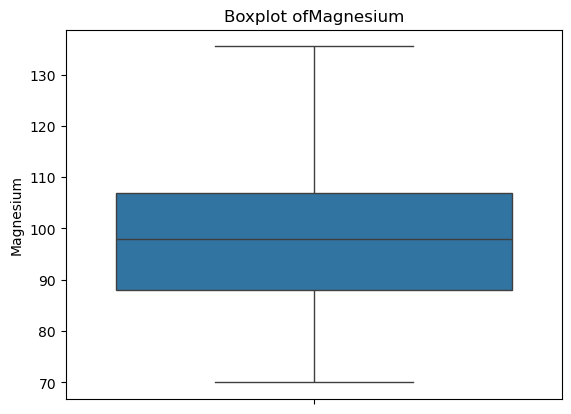

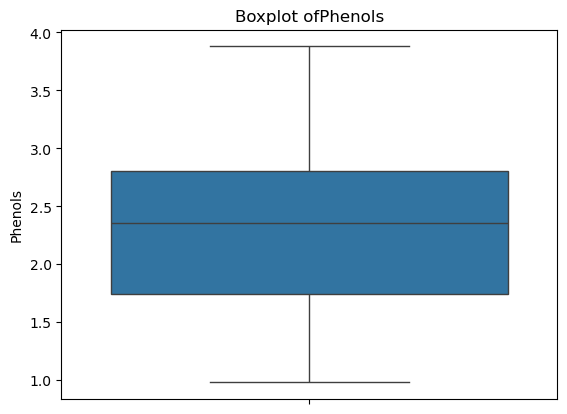

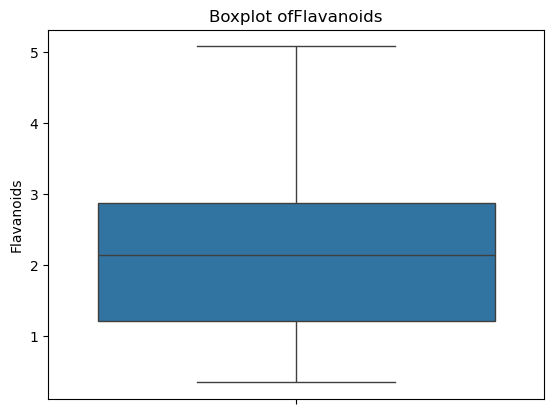

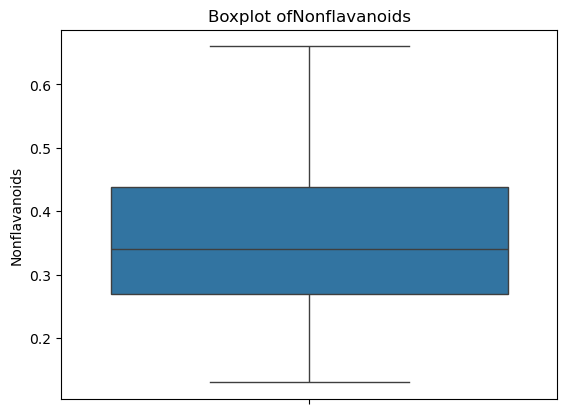

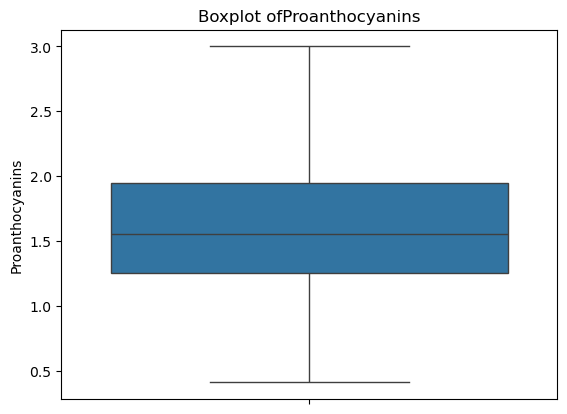

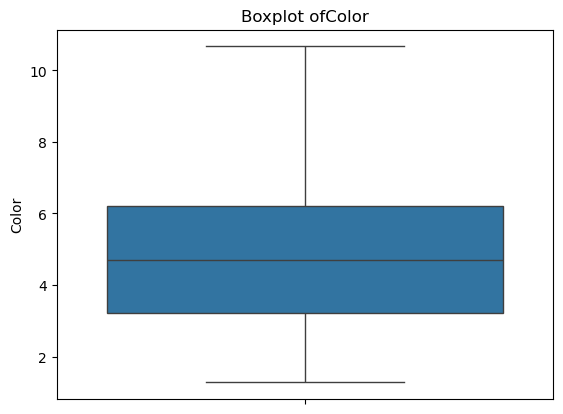

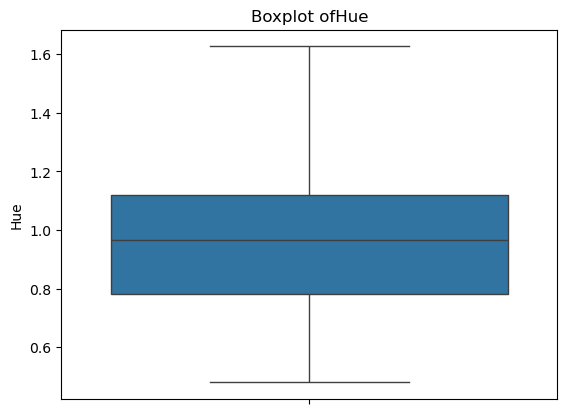

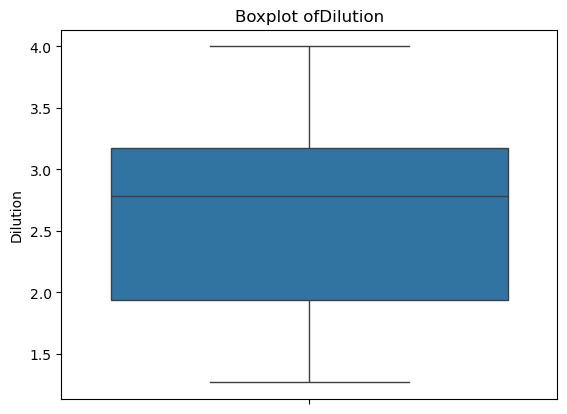

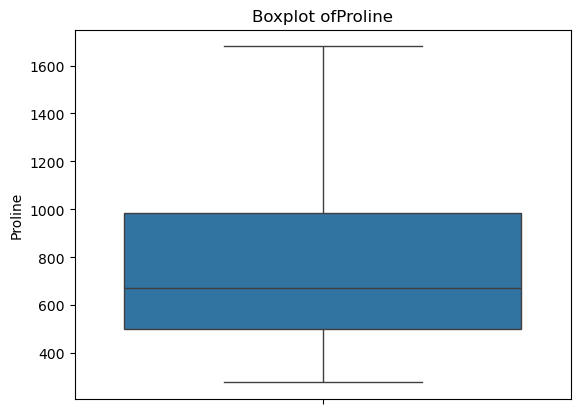

In [11]:
for col in df.select_dtypes(include=['int','float']).columns:
    sns.boxplot(df[col])
    plt.title(f"Boxplot of{col}")
    plt.show()

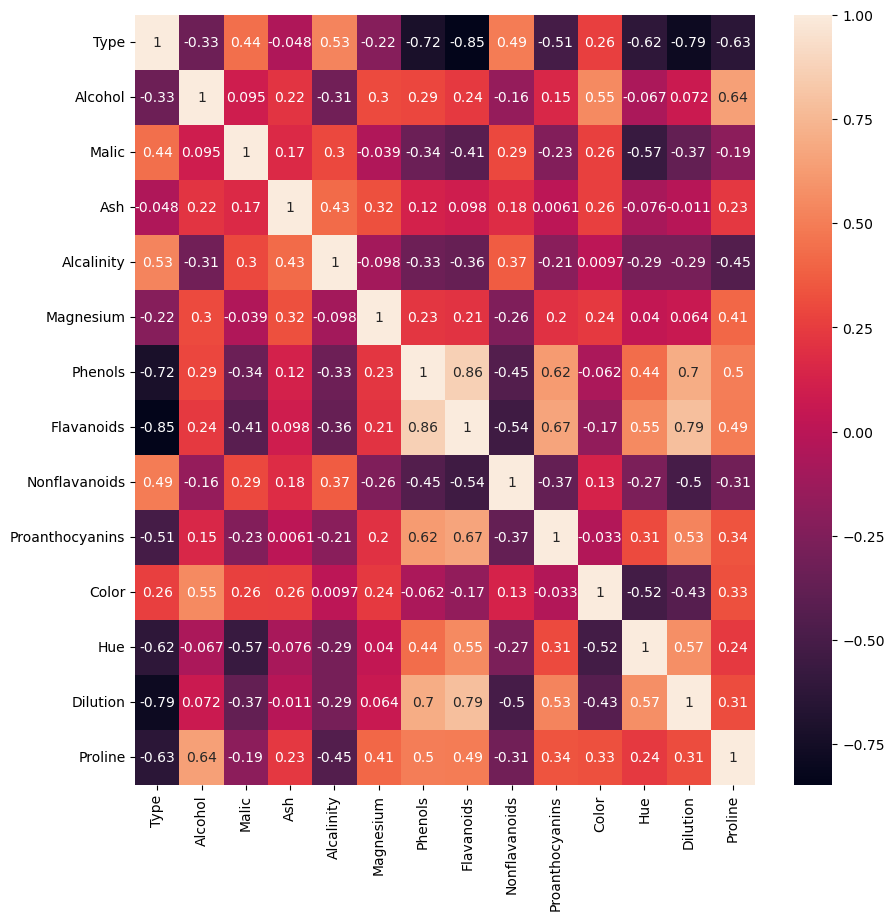

In [12]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

In [34]:
# standerdize
from sklearn.preprocessing import StandardScaler
X = df.drop("Type", axis=1)
y = df["Type"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [35]:
from sklearn.decomposition import PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

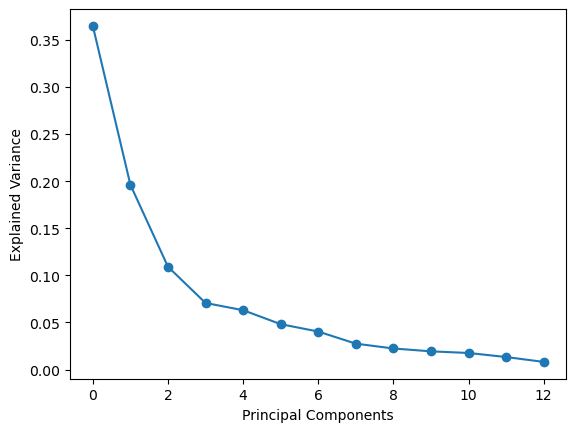

In [36]:
plt.plot(pca.explained_variance_ratio_, marker='o')
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance")
plt.show()

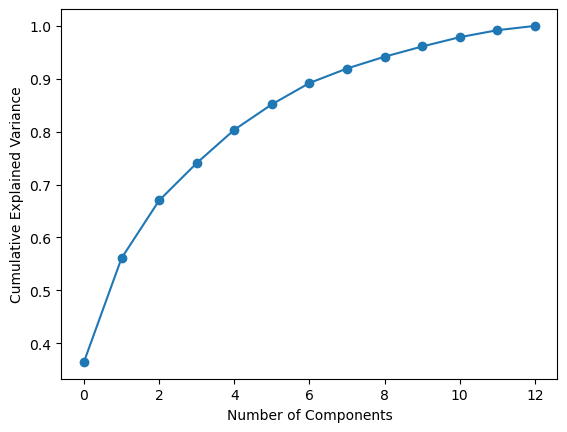

In [37]:
# Explained Variance
cum_var = np.cumsum(pca.explained_variance_ratio_)
plt.plot(cum_var, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.show()

In [38]:
pca_opt = PCA(n_components=5)
X_reduced = pca_opt.fit_transform(X_scaled)
print("Reduced Shape:", X_reduced.shape)

Reduced Shape: (178, 5)


In [39]:
X_reduced = pd.DataFrame(X_reduced)
print(X_reduced.head())

          0         1         2         3         4
0  3.358147  1.520222 -0.126375 -0.224356  0.710891
1  2.229215 -0.333261 -2.042838 -0.365783 -0.107448
2  2.540057  1.036953  1.018845  0.766907 -0.363113
3  3.781124  2.782566 -0.149224  0.593304 -0.273054
4  1.016872  0.955225  2.113169 -0.431732  0.357108


In [40]:
from sklearn.cluster import KMeans
# Choose number of clusters (start with 3 for wine dataset)
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
# Add cluster labels to dataset
df["Cluster"] = clusters

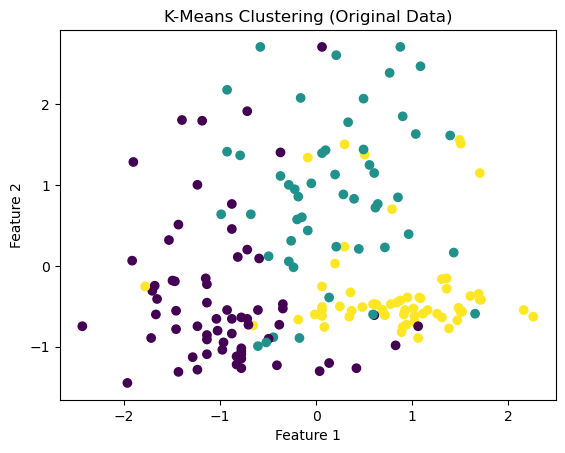

In [41]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means Clustering (Original Data)")
plt.show()

In [42]:
from sklearn.metrics import silhouette_score
sil_score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", sil_score)

Silhouette Score: 0.2854626783251893


In [43]:
from sklearn.metrics import davies_bouldin_score

db_score = davies_bouldin_score(X_scaled, clusters)
print("Davies-Bouldin Index:", db_score)

Davies-Bouldin Index: 1.3816062413276704


In [44]:
# with PCA
from sklearn.cluster import KMeans
kmeans_pca = KMeans(n_clusters=3, random_state=42)
clusters_pca = kmeans_pca.fit_predict(X_reduced)

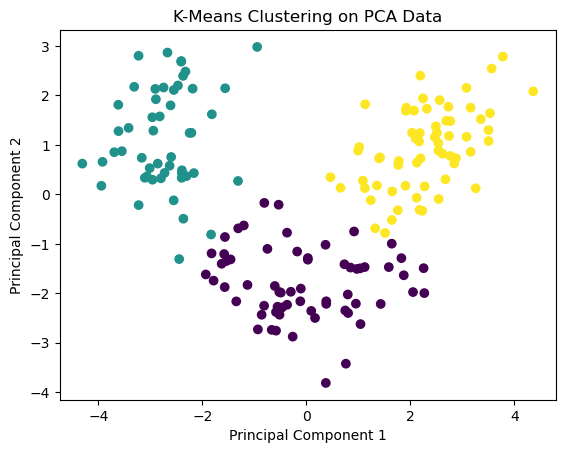

In [45]:
plt.scatter(X_reduced.iloc[:, 0], X_reduced.iloc[:, 1], c=clusters_pca)
plt.title("K-Means Clustering on PCA Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [46]:
from sklearn.metrics import silhouette_score, davies_bouldin_score
sil_pca = silhouette_score(X_reduced, clusters_pca)
db_pca = davies_bouldin_score(X_reduced, clusters_pca)
print("PCA Silhouette Score:", sil_pca)
print("PCA Davies-Bouldin Index:", db_pca)

PCA Silhouette Score: 0.3681209363997655
PCA Davies-Bouldin Index: 1.0882646669885137


In [47]:
print("Original Silhouette:", sil_score)
print("PCA Silhouette:", sil_pca)
print("Original DB Index:", db_score)
print("PCA DB Index:", db_pca)

Original Silhouette: 0.2854626783251893
PCA Silhouette: 0.3681209363997655
Original DB Index: 1.3816062413276704
PCA DB Index: 1.0882646669885137


1. Comparison of Clustering Results:
Clustering was performed on both the original dataset and the PCA-transformed dataset. The PCA-based clustering showed more compact and well-separated clusters compared to the original data, where clusters were slightly overlapping due to high dimensionality and redundant features.
Therefore,clustering on pca data is giving better results for this dataset.

2. Similarities and Differences:
Both approaches identified similar grouping patterns in the data. However, clustering on the original dataset was more affected by noise and correlated features, while PCA-based clustering produced clearer boundaries between clusters.

3. Impact of Dimensionality Reduction:
Dimensionality reduction using PCA improved clustering performance by removing redundant information and reducing noise. This led to better separation of clusters and improved evaluation metrics such as silhouette score.
Usually dimensionality reduction is one of the best methods for improved results, where it removes unwanted noise's raised.

4. Trade-offs:
Using PCA reduces dimensionality and improves clustering quality and visualization. However, it may result in some loss of information and interpretability of original features. Clustering on the original dataset preserves full information but may suffer from lower performance due to high dimensionality.

Conclusion and Insights:
1.The assignment demonstrated that PCA effectively reduces dimensionality while preserving most of the important information in the dataset. Clustering on PCA-transformed data produced more compact and well-separated clusters compared to the original dataset.
2.In practical applications, PCA helps simplify complex data, reduce noise, and improve the performance of algorithms like clustering. It is especially useful when dealing with high-dimensional data.
3.The technique is mostly preferred when there is enormus amount data can be said as high dimentionality data where it will ealuate the dataset and give better results accordingly.